# BOCSAR Crime Data — EDA

## Overview
This notebook performs exploratory data analysis (EDA) on the cleaned BOCSAR crime dataset for the five MVP suburbs: Newtown, Glebe, Redfern, Surry Hills, and Haymarket.

## Data Source
`data/processed/bocsar_clean.csv` — produced by `01_bocsar_clean.ipynb`

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Load cleaned CSV
base_path = os.path.dirname(os.path.dirname(os.path.abspath("__file__")))
df = pd.read_csv(os.path.join(base_path, "data/processed/bocsar_clean.csv"))

print("Shape:", df.shape)
print("\nSuburbs:", df['suburb'].unique())
print("\nCrime types:", df['crime_type'].nunique(), "unique categories")
df.head()

Shape: (310, 5)

Suburbs: ['Glebe' 'Haymarket' 'Newtown' 'Redfern' 'Surry Hills']

Crime types: 21 unique categories


,suburb,sa4_area,crime_type,year,incident_count
0,Glebe,NaN,Homicide,2024-2025,0.000000
1,Glebe,NaN,Homicide,2024-2025,0.000000
2,Glebe,NaN,Homicide,2024-2025,0.000000
3,Glebe,NaN,Homicide,2024-2025,0.041667
4,Glebe,NaN,Assault,2024-2025,7.541667


In [15]:
# Fix sa4_area NaN
df['sa4_area'] = df['sa4_area'].fillna('N/A')

# Total incident count per suburb
suburb_total = df.groupby('suburb')['incident_count'].sum().sort_values(ascending=False).reset_index()
suburb_total.columns = ['suburb', 'total_incidents']
print(suburb_total)

        suburb  total_incidents
0    Haymarket       505.833333
1  Surry Hills       320.625000
2      Redfern       304.541667
3        Glebe       210.708333
4      Newtown       180.458333


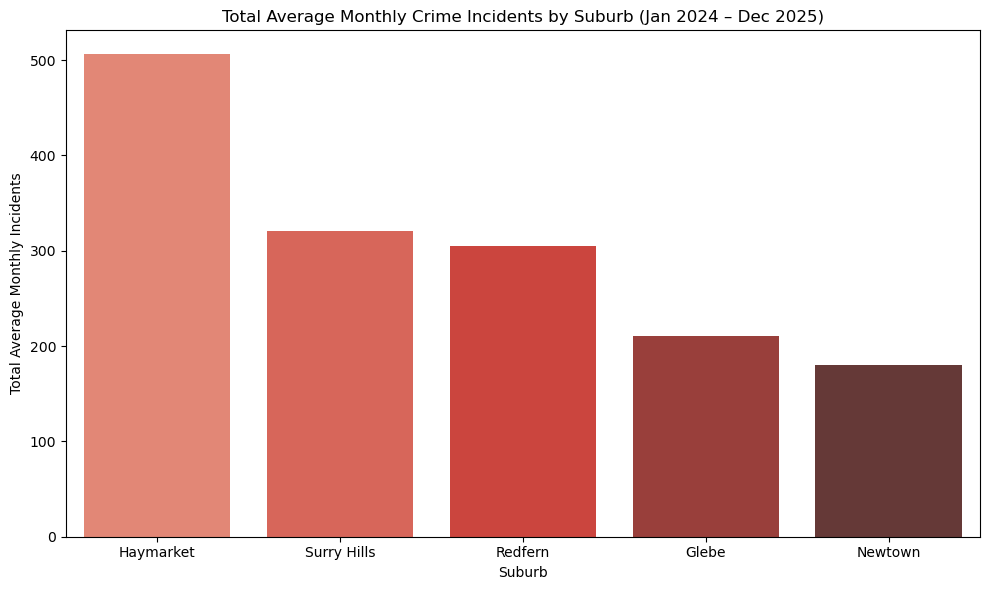

In [16]:
# Bar chart: Total incidents per suburb

plt.figure(figsize=(10, 6))
sns.barplot(data=suburb_total, x='suburb', y='total_incidents', hue='suburb', palette='Reds_d', legend=False)
plt.title('Total Average Monthly Crime Incidents by Suburb (Jan 2024 – Dec 2025)')
plt.xlabel('Suburb')
plt.ylabel('Total Average Monthly Incidents')
plt.tight_layout()
plt.savefig(os.path.join(base_path, 'notebooks/figs/bocsar_suburb_total.png'))
plt.show()

In [17]:
# Top 5 crime types per suburb

top5_per_suburb = (
    df.groupby(['suburb', 'crime_type'])['incident_count']
    .sum()
    .reset_index()
    .sort_values(['suburb', 'incident_count'], ascending=[True, False])
    .groupby('suburb')
    .head(5)
)

print(top5_per_suburb.to_string(index=False))

     suburb                            crime_type  incident_count
      Glebe                                 Theft       75.166667
      Glebe            Against justice procedures       50.250000
      Glebe                               Assault       22.916667
      Glebe          Malicious damage to property       13.833333
      Glebe Intimidation, stalking and harassment       12.916667
  Haymarket         Transport regulatory offences      243.083333
  Haymarket                                 Theft       85.500000
  Haymarket                         Drug offences       43.833333
  Haymarket                               Assault       33.458333
  Haymarket            Against justice procedures       22.625000
    Newtown                                 Theft       46.875000
    Newtown            Against justice procedures       39.166667
    Newtown                               Assault       19.083333
    Newtown         Transport regulatory offences       15.416667
    Newtow

## EDA Summary

### Key Findings

1. **Haymarket** has the highest total crime incidents, driven significantly by Transport Regulatory Offences (243 average monthly incidents), likely due to its proximity to Central Station.

2. **Redfern** has the highest Against Justice Procedures count (109), indicating high rates of bail breaches and AVO violations.

3. **Theft** is consistently the top property crime across all five suburbs.

4. **Newtown** has the lowest overall crime rate among the five suburbs.

### Limitations

- `incident_count` represents the average monthly incidents over 24 months (Jan 2024 – Dec 2025), not a raw count.
- `sa4_area` is set to N/A as suburb-level data was sourced directly from BOCSAR.
- Zero-incident cells appear white in the heatmap due to log-scale transformation.